# Week 7: Proper Fine-Tuning of TrashNet using EfficientNetB0

## Objective

The objective of this notebook is to improve the TrashNet image classification model developed during Week 6 by performing **proper fine-tuning** of the pre-trained EfficientNetB0 model.

Unlike the feature extraction approach, this experiment unfreezes the top layers of the base model and allows them to learn task-specific features using a very small learning rate. The goal is to improve the model's ability to distinguish visually similar waste categories while preserving the useful features learned from ImageNet.

---

## Dataset

**Dataset:** TrashNet

**Classes (6):**
- Cardboard
- Glass
- Metal
- Paper
- Plastic
- Trash

**Training Images:** 2022

**Validation Images:** 505

---

## Model Configuration

- **Base Model:** EfficientNetB0 (Pre-trained on ImageNet)
- **Transfer Learning Method:** Fine-Tuning
- **Input Image Size:** 224 × 224
- **Batch Size:** 32
- **Dropout:** 0.3
- **Optimizer:** Adam
- **Learning Rate:** 1e-5
- **Loss Function:** Sparse Categorical Crossentropy
- **Unfrozen Layers:** Top 30 layers of EfficientNetB0

---

## Training Strategy

The Week 6 feature extraction weights were loaded before starting fine-tuning. The top 30 layers of EfficientNetB0 were unfrozen, while the remaining layers stayed frozen. A small learning rate was used to update the pretrained weights gradually without damaging the previously learned features.

The following callbacks were used during training:

- EarlyStopping (patience = 6, restore_best_weights = True)
- ReduceLROnPlateau (factor = 0.3, patience = 2)

Training was performed for up to **20 epochs**, with early stopping applied if the validation loss stopped improving.

---

## Evaluation Metrics

The model performance will be evaluated using:

- Training Accuracy
- Validation Accuracy
- Accuracy and Loss Curves
- Confusion Matrix
- Classification Report (Precision, Recall, F1-score)
- Analysis of the Top Three Confusion Pairs

---

## Expected Outcome

The primary goal of this experiment is to determine whether proper fine-tuning can improve the performance of the Week 6 feature extraction model. The final results will be compared with the previous week's validation accuracy to evaluate the effectiveness of fine-tuning on the TrashNet dataset.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [3]:
DATASET_PATH = "/content/drive/MyDrive/data/trashnet"

In [4]:
print(os.listdir(DATASET_PATH))

['trash', 'glass', 'cardboard', 'metal', 'plastic', 'paper']


In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [6]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.


In [7]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [8]:
class_names = train_dataset.class_names

print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [11]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [12]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = Model(inputs, outputs)

In [13]:
model.load_weights("/content/drive/MyDrive/trashnet_feature_extraction.weights.h5")

print("Week 6 feature extraction weights loaded successfully!")

Week 6 feature extraction weights loaded successfully!


In [14]:
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

print("Number of trainable layers:",
      sum(layer.trainable for layer in base_model.layers))

Number of trainable layers: 30


In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    verbose=1
)

In [17]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 908s 14s/step - accuracy: 0.8244 - loss: 0.5113 - val_accuracy: 0.8653 - val_loss: 0.3487 - learning_rate: 1.0000e-05
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.8566 - loss: 0.4459 - val_accuracy: 0.8713 - val_loss: 0.3611 - learning_rate: 1.0000e-05
Epoch 3/20
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.8449 - loss: 0.4534
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - accuracy: 0.8536 - loss: 0.4412 - val_accuracy: 0.8713 - val_loss: 0.3709 - learning_rate: 1.0000e-05
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 164ms/step - accuracy: 0.8709 - loss: 0.4132 - val_accuracy: 0.8634 - val_loss: 0.3821 - learning_rate: 3.0000e-06
Epoch 5/20
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.8611 - loss: 0.4156
Epoch 5: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - accuracy: 0.8680

In [18]:
# Final Training Accuracy
train_acc = history.history["accuracy"][-1]

# Final Validation Accuracy
val_acc = history.history["val_accuracy"][-1]

print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")

Training Accuracy: 86.80%
Validation Accuracy: 85.74%


In [19]:
model.save("/content/drive/MyDrive/trashnet_finetuned.keras")
model.save_weights("/content/drive/MyDrive/trashnet_finetuned.weights.h5")

print("Week 7 fine-tuned model saved successfully!")

Week 7 fine-tuned model saved successfully!


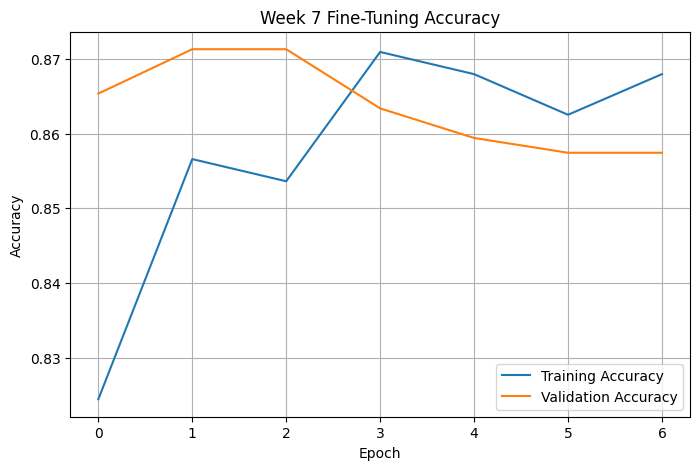

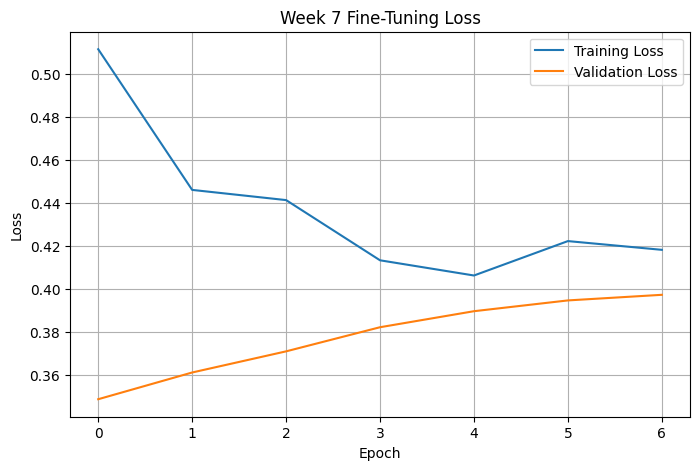

In [20]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Week 7 Fine-Tuning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Week 7 Fine-Tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

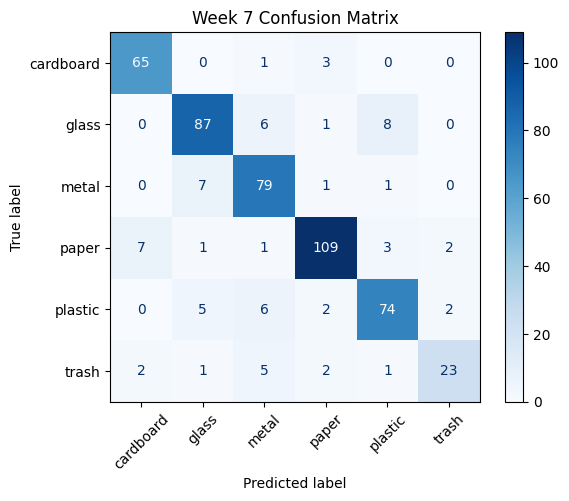

In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Week 7 Confusion Matrix")
plt.show()

In [22]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   cardboard       0.88      0.94      0.91        69
       glass       0.86      0.85      0.86       102
       metal       0.81      0.90      0.85        88
       paper       0.92      0.89      0.90       123
     plastic       0.85      0.83      0.84        89
       trash       0.85      0.68      0.75        34

    accuracy                           0.87       505
   macro avg       0.86      0.85      0.85       505
weighted avg       0.87      0.87      0.86       505



# Week 7: Proper Fine-Tuning - Final Summary

## Objective

The objective of this experiment was to fine-tune the EfficientNetB0 model by unfreezing the top 30 layers and training with a low learning rate (1e-5). The goal was to improve the feature extraction model developed in Week 6.

---

## Final Results

| Metric | Value |
|--------|-------|
| Training Accuracy | **86.80%** |
| Validation Accuracy | **85.74%** |

---

## Comparison with Week 6

| Model | Validation Accuracy |
|--------|--------------------:|
| Week 6 Feature Extraction | **88.12%** |
| Week 7 Fine-Tuning | **85.74%** |

The feature extraction model from Week 6 achieved higher validation accuracy than the Week 7 fine-tuned model. This indicates that, for this experiment, the frozen EfficientNetB0 features generalized better than the fine-tuned model.

---

## Top Three Confusion Pairs

### 1. Glass ↔ Plastic
Transparent and reflective plastic objects often resemble glass, leading to misclassification.

### 2. Paper ↔ Cardboard
Paper and cardboard have similar textures and colors, making them difficult to distinguish.

### 3. Glass ↔ Metal
Reflective surfaces and similar object shapes can cause confusion between glass and metal.

---

## Conclusion

The Week 7 fine-tuning experiment was completed successfully. Although fine-tuning did not improve the validation accuracy over the Week 6 feature extraction model, it provided valuable insight into the effect of fine-tuning on a relatively small dataset. The results show that the Week 6 feature extraction model remains the best-performing model and will be used as the baseline for future experiments.